# Test Evaluation Visualization
Compare seed-42 ANN + TF-IDF and LSTM + Word2Vec test-set metrics and confusion matrices.

In [1]:
from pathlib import Path
import sys
import joblib
import torch
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

REPORT_DIR = PROJECT_ROOT / 'report'
FIGURE_DIR = REPORT_DIR / 'figures'
MODELS_DIR = PROJECT_ROOT / 'models'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
LABEL_NAMES = ['Negative', 'Neutral', 'Positive']
sns.set_theme(style='whitegrid')


## 1) Load test summaries and seed-42 artifacts

In [2]:
with open(REPORT_DIR / 'ann_tfidf_test_seed_summary.yaml', 'r', encoding='utf-8') as f:
    ann_summary = yaml.safe_load(f)

with open(REPORT_DIR / 'lstm_w2vec_test_seed_summary.yaml', 'r', encoding='utf-8') as f:
    lstm_summary = yaml.safe_load(f)

ann_metrics = ann_summary['metrics_by_seed'][SEED]
lstm_metrics = lstm_summary['metrics_by_seed'][SEED]

artifact_paths = {
    'ann_model': MODELS_DIR / f'ann_tfidf_seed{SEED}_best_model.pt',
    'ann_tfidf_vectorizer': MODELS_DIR / f'ann_tfidf_seed{SEED}_tfidf_vectorizer.pkl',
    'lstm_model': MODELS_DIR / f'lstm_w2vec_seed{SEED}_best_model.pt',
    'lstm_embedding_matrix': MODELS_DIR / f'lstm_w2vec_seed{SEED}_embedding_matrix.pt',
}

missing = [str(path) for path in artifact_paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError(f'Missing expected seed-{SEED} artifacts: {missing}')

ann_vectorizer = joblib.load(artifact_paths['ann_tfidf_vectorizer'])
ann_checkpoint = torch.load(artifact_paths['ann_model'], map_location='cpu')
lstm_checkpoint = torch.load(artifact_paths['lstm_model'], map_location='cpu')
lstm_embedding_matrix = torch.load(artifact_paths['lstm_embedding_matrix'], map_location='cpu')

{
    'ann_model_epoch': ann_checkpoint.get('epoch'),
    'lstm_model_epoch': lstm_checkpoint.get('epoch'),
    'ann_tfidf_features': len(ann_vectorizer.vocabulary_),
    'lstm_embedding_matrix_shape': tuple(lstm_embedding_matrix.shape),
}


{'ann_model_epoch': 9,
 'lstm_model_epoch': 18,
 'ann_tfidf_features': 1000,
 'lstm_embedding_matrix_shape': (2059, 100)}

## 2) Side-by-side confusion matrices

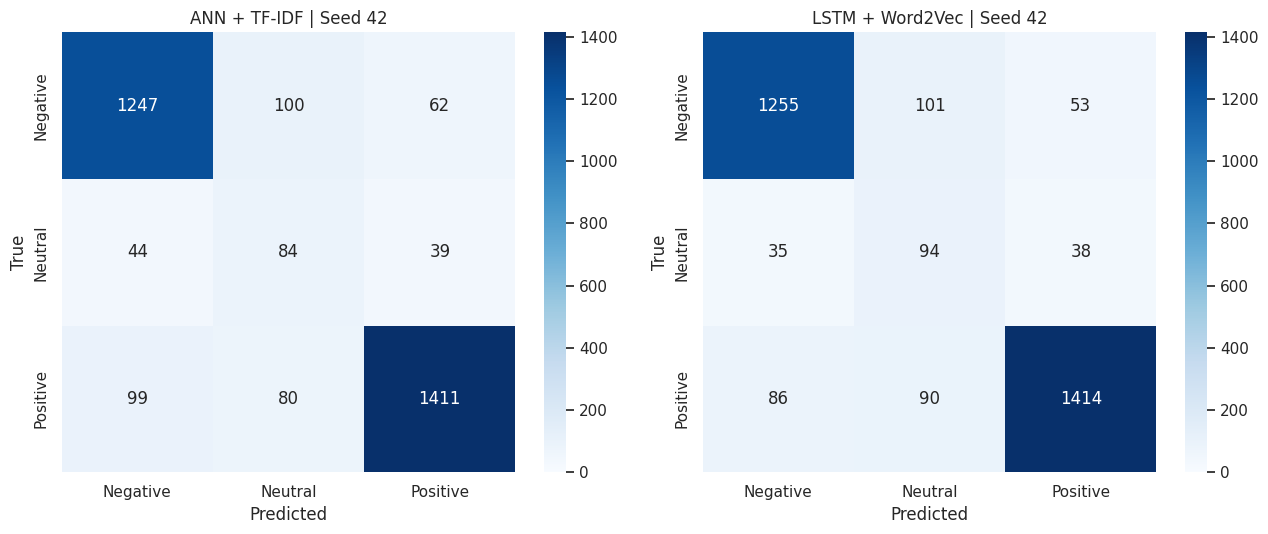

PosixPath('/home/coronny/sentiment_analysis/report/figures/test_seed42_confusion_comparison.png')

In [3]:
ann_cm = np.array(ann_metrics['confusion_matrix'])
lstm_cm = np.array(lstm_metrics['confusion_matrix'])

vmax = max(ann_cm.max(), lstm_cm.max())
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

sns.heatmap(
    ann_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    vmin=0,
    vmax=vmax,
    cbar=True,
    ax=axes[0],
)
axes[0].set_title(f'ANN + TF-IDF | Seed {SEED}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(
    lstm_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    vmin=0,
    vmax=vmax,
    cbar=True,
    ax=axes[1],
)
axes[1].set_title(f'LSTM + Word2Vec | Seed {SEED}')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

fig.tight_layout()
cm_path = FIGURE_DIR / f'test_seed{SEED}_confusion_comparison.png'
fig.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()
cm_path


## 3) Test metrics comparison

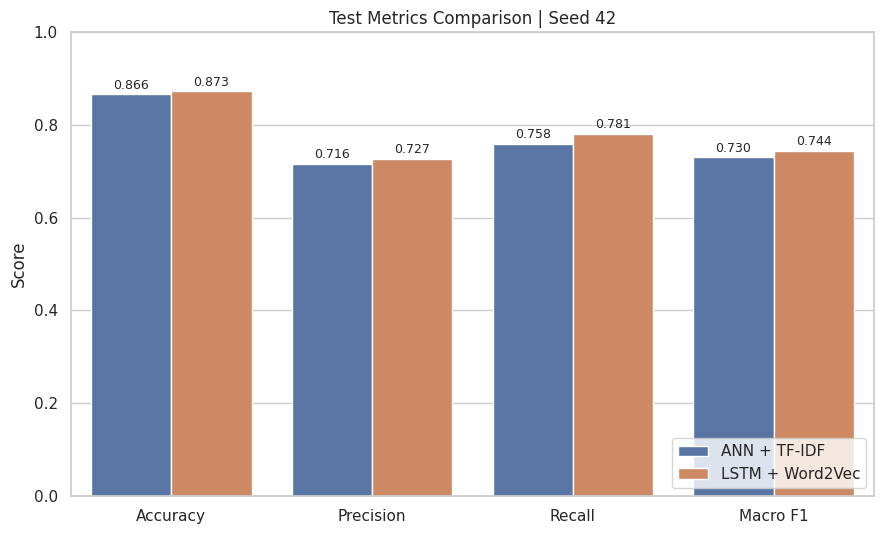

PosixPath('/home/coronny/sentiment_analysis/report/figures/test_seed42_metrics_comparison.png')

In [4]:
metric_labels = {
    'final_test_accuracy': 'Accuracy',
    'final_test_precision': 'Precision',
    'final_test_recall': 'Recall',
    'final_test_f1': 'Macro F1',
}

metric_rows = []
for key, label in metric_labels.items():
    metric_rows.append({'Metric': label, 'Model': 'ANN + TF-IDF', 'Score': ann_metrics[key]})
    metric_rows.append({'Metric': label, 'Model': 'LSTM + Word2Vec', 'Score': lstm_metrics[key]})

metrics_df = pd.DataFrame(metric_rows)

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Model', ax=ax)
ax.set_ylim(0, 1)
ax.set_title(f'Test Metrics Comparison | Seed {SEED}')
ax.set_xlabel('')
ax.set_ylabel('Score')

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9, padding=2)

ax.legend(loc='lower right')
fig.tight_layout()
metrics_path = FIGURE_DIR / f'test_seed{SEED}_metrics_comparison.png'
fig.savefig(metrics_path, dpi=300, bbox_inches='tight')
plt.show()
metrics_path


## 4) Seed-42 metric table

In [5]:
table_df = metrics_df.pivot(index='Metric', columns='Model', values='Score').reset_index()
table_df['Delta (LSTM - ANN)'] = table_df['LSTM + Word2Vec'] - table_df['ANN + TF-IDF']
table_df


Model,Metric,ANN + TF-IDF,LSTM + Word2Vec,Delta (LSTM - ANN)
0,Accuracy,0.866077,0.872710,0.006633
1,Macro F1,0.730186,0.743639,0.013453
2,Precision,0.716168,0.727141,0.010973
3,Recall,0.758480,0.780962,0.022482
